# PED tblastn Validation

Notebook này validate độ chính xác tblastn lifting cho PED với **2 reference**:

- `PED_ref_1.gb`
- `PED_ref_2.gb`

Cách tính accuracy: với từng gene trong reference, chỉ đánh giá trên các query records **thực sự có gene đó trong truth annotation**. Ví dụ nếu một record chỉ có `ORF1ab` gộp thì record đó không được dùng làm denominator cho `ORF1a`/`ORF1b`.

Notebook này có chạy tblastn nên sẽ lâu nếu chạy full 100 records x 2 refs. Mặc định notebook chạy sample nhỏ để smoke test trước; muốn chạy full thì đổi `RUN_FULL_100 = True` trong cell settings.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO
from tqdm.auto import tqdm

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'app' / 'src').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.validation._shared.validation_utils import (
    compare_predictions_to_truth,
    lifted_to_rows,
    load_reference_bundle,
)
from app.src.alias.gene_alias import apply_alias_to_features
from app.src.io.genbank_parser import parse_cds_features, load_genbank_records
from app.src.lifting.tblastn_lifter import lift_all_tblastn

DATA_DIR = ROOT / 'app' / 'data' / 'PED'
OUTPUT_DIR = ROOT / 'app' / 'validation' / '06_ped_validation' / 'outputs' / 'tblastn'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REFS = {
    'ref_1': DATA_DIR / 'PED_ref_1.gb',
    'ref_2': DATA_DIR / 'PED_ref_2.gb',
}
QUERY_PATH = DATA_DIR / 'PED_100seqs.gb'

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 120)

## Load References And Query Records

In [3]:
query_records = load_genbank_records(QUERY_PATH)
bundles = {label: load_reference_bundle(path) for label, path in REFS.items()}

# ---- Run settings ----
# Smoke test nhanh: giữ False để chạy SAMPLE_N records đầu tiên.
# Validation full: đổi thành True để chạy toàn bộ 100 records.
RUN_FULL_100 = True
SAMPLE_N = 10
REF_LABELS_TO_RUN = ['ref_1', 'ref_2']  # có thể đổi thành ['ref_1'] nếu muốn test một ref trước

selected_query_records = query_records if RUN_FULL_100 else query_records[:SAMPLE_N]
selected_bundles = {label: bundles[label] for label in REF_LABELS_TO_RUN}
RUN_SUFFIX = 'full100' if RUN_FULL_100 else f'sample{len(selected_query_records)}'

ref_model_rows = []
for label, bundle in bundles.items():
    for feature in bundle['features']:
        ref_model_rows.append({
            'ref': label,
            'ref_record': bundle['record'].id,
            'feature_type': bundle['feature_type'],
            'gene': feature['name'],
            'start': feature['start'],
            'end': feature['end'],
            'length': feature['end'] - feature['start'] + 1,
            'name_source': feature.get('name_source'),
            'raw_name': feature.get('raw_name'),
        })
ref_model = pd.DataFrame(ref_model_rows)
ref_model.to_csv(OUTPUT_DIR / 'ped_ref_models.tsv', sep='	', index=False)

print('Total query records:', len(query_records))
print('Selected query records for this run:', len(selected_query_records))
print('Selected refs:', REF_LABELS_TO_RUN)
print('Run suffix:', RUN_SUFFIX)
ref_model

Total query records: 100
Selected query records for this run: 100
Selected refs: ['ref_1', 'ref_2']
Run suffix: full100


,ref,ref_record,feature_type,gene,start,end,length,name_source,raw_name
0,ref_1,PZ105934.1,CDS,ORF1a,293,12646,12354,alias,ORF1a
1,ref_1,PZ105934.1,CDS,ORF1b,12811,20637,7827,alias,ORF1b
2,ref_1,PZ105934.1,CDS,S,20634,24794,4161,alias,S
3,ref_1,PZ105934.1,CDS,ORF3,24794,25468,675,alias,ORF3
4,ref_1,PZ105934.1,CDS,E,25449,25679,231,alias,E
5,ref_1,PZ105934.1,CDS,M,25687,26367,681,alias,M
6,ref_1,PZ105934.1,CDS,N,26379,27704,1326,alias,N
7,ref_2,PV974486.1,CDS,ORF1a,271,12624,12354,alias,ORF1a
8,ref_2,PV974486.1,CDS,ORF1b,12594,20615,8022,alias,ORF1b
9,ref_2,PV974486.1,CDS,S,20612,24760,4149,alias,S


## Truth Availability Audit

Bảng này cho biết trong 100 query records, mỗi gene có truth annotation ở bao nhiêu records. `ORF1ab` được giữ riêng để tránh ép vùng gộp vào `ORF1a` hoặc `ORF1b`.

In [4]:
alias_lookup = next(iter(bundles.values()))['alias_lookup']
truth_rows = []
for record in query_records:
    for feature in apply_alias_to_features(parse_cds_features(record), alias_lookup):
        truth_rows.append({
            'record_id': record.id,
            'truth_name': feature['name'],
            'source': feature.get('name_source'),
            'start': feature['start'],
            'end': feature['end'],
            'length': feature['end'] - feature['start'] + 1,
            'raw_name': feature.get('raw_name'),
            'gene': feature.get('gene'),
            'product': feature.get('product'),
            'note': feature.get('note'),
        })
truth_all = pd.DataFrame(truth_rows)
truth_all.to_csv(OUTPUT_DIR / 'ped_truth_features_all.tsv', sep='	', index=False)

truth_presence = (
    truth_all[truth_all['source'].isin(['alias', 'alias_conflict_resolved'])]
    .groupby('truth_name')
    .agg(records=('record_id', 'nunique'), features=('record_id', 'size'), main_source=('source', lambda s: s.value_counts().idxmax()))
    .reset_index()
    .sort_values(['records', 'truth_name'], ascending=[False, True])
)
truth_presence.to_csv(OUTPUT_DIR / 'ped_truth_presence.tsv', sep='	', index=False)
truth_presence

,truth_name,records,features,main_source
1,M,97,97,alias
2,N,97,97,alias
7,S,97,97,alias
0,E,96,96,alias
6,ORF3,91,91,alias
4,ORF1ab,62,65,alias_conflict_resolved
3,ORF1a,17,17,alias
5,ORF1b,8,8,alias


## Run tblastn For Selected References

Cell này rerun tblastn từ đầu cho `selected_query_records` và `REF_LABELS_TO_RUN`.

Mặc định notebook chạy sample nhỏ để kiểm tra notebook/code không lỗi. Muốn validate full thì lên cell settings đổi:

```python
RUN_FULL_100 = True
```

Logic scoring:

- Prediction name phải có same-name truth trong query record.
- `exact`: start/end khớp tuyệt đối với truth.
- `coord_correct`: IoU >= 0.90 với same-name truth.
- Records không có truth gene tương ứng không được tính vào denominator của gene đó.


In [5]:
def truth_features_for_ref(record, alias_lookup, target_names):
    features = apply_alias_to_features(parse_cds_features(record), alias_lookup)
    return [
        feature for feature in features
        if feature.get('name') in target_names
        and feature.get('name_source') in ('alias', 'alias_conflict_resolved')
    ]

all_compared = []
for ref_label, bundle in selected_bundles.items():
    target_names = sorted({feature['name'] for feature in bundle['features']})
    iterator = tqdm(selected_query_records, desc=f'PED tblastn {ref_label}', unit='record')
    for record in iterator:
        truth = truth_features_for_ref(record, bundle['alias_lookup'], target_names)
        if not truth:
            continue
        iterator.set_postfix_str(record.id)
        lifted = lift_all_tblastn(
            ref_features=bundle['features'],
            ref_record=bundle['record'],
            query_record=record,
            validate_codons=(bundle['feature_type'] == 'CDS'),
        )
        preds = lifted_to_rows(record.id, lifted, 'tblastn')
        compared = compare_predictions_to_truth(preds, truth, iou_threshold=0.90)
        compared.insert(0, 'ref', ref_label)
        compared.insert(1, 'ref_record', bundle['record'].id)
        all_compared.append(compared)

ped_tblastn_df = pd.concat(all_compared, ignore_index=True) if all_compared else pd.DataFrame()
ped_tblastn_df.to_csv(OUTPUT_DIR / f'ped_tblastn_vs_truth_{RUN_SUFFIX}.tsv', sep='	', index=False)
ped_tblastn_df.head(20)

PED tblastn ref_1:   0%|          | 0/100 [00:00<?, ?record/s]

PED tblastn ref_2:   0%|          | 0/100 [00:00<?, ?record/s]

,ref,ref_record,record_id,method,ref_name,pred_name,source_name,pred_start,pred_end,strand,...,truth_name,truth_start,truth_end,best_overlap_name,best_iou,iou,name_match,coord_correct,exact_match,failure_mode
0,ref_1,PZ105934.1,EF185992.1,tblastn,ORF1a,ORF1a,None,297,12650,+,...,NaN,NaN,NaN,NaN,0.0000,0.0000,False,False,False,Not in truth
1,ref_1,PZ105934.1,EF185992.1,tblastn,ORF1b,ORF1b,None,12815,20641,+,...,NaN,NaN,NaN,S,0.0003,0.0000,False,False,False,Possible overlap
2,ref_1,PZ105934.1,EF185992.1,tblastn,S,S,None,20638,24789,+,...,S,20638.0,24789.0,S,1.0000,1.0000,True,True,True,Correct
3,ref_1,PZ105934.1,EF185992.1,tblastn,ORF3,ORF3,None,24789,25463,+,...,ORF3,24789.0,25463.0,ORF3,1.0000,1.0000,True,True,True,Correct
4,ref_1,PZ105934.1,EF185992.1,tblastn,E,E,None,25444,25674,+,...,NaN,NaN,NaN,ORF3,0.0226,0.0000,False,False,False,Possible overlap
5,ref_1,PZ105934.1,EF185992.1,tblastn,M,M,None,25682,26362,+,...,M,25682.0,26362.0,M,1.0000,1.0000,True,True,True,Correct
6,ref_1,PZ105934.1,EF185992.1,tblastn,N,N,None,26374,27699,+,...,N,26374.0,27699.0,N,1.0000,1.0000,True,True,True,Correct
7,ref_1,PZ105934.1,KM189367.2,tblastn,ORF1a,ORF1a,None,293,12646,+,...,NaN,NaN,NaN,NaN,0.0000,0.0000,False,False,False,Not in truth
8,ref_1,PZ105934.1,KM189367.2,tblastn,ORF1b,ORF1b,None,12811,20637,+,...,NaN,NaN,NaN,S,0.0003,0.0000,False,False,False,Possible overlap
9,ref_1,PZ105934.1,KM189367.2,tblastn,S,S,None,20634,24794,+,...,S,20634.0,24794.0,S,1.0000,1.0000,True,True,True,Correct


## Overall Accuracy By Reference

`correct_pct = (exact + coord_only) / total`, chỉ tính các gene-record cases có truth tương ứng.

In [6]:
def summarize_truth_available(df, group_cols):
    evaluable = df[df['truth_name'].notna()].copy()
    summary = (
        evaluable.groupby(group_cols, dropna=False)
        .agg(
            total=('record_id', 'size'),
            exact=('exact_match', lambda s: int(s.fillna(False).sum())),
            coord_correct=('coord_correct', lambda s: int(s.fillna(False).sum())),
            mean_iou=('iou', 'mean'),
        )
        .reset_index()
    )
    summary['coord_only'] = summary['coord_correct'] - summary['exact']
    summary['failed'] = summary['total'] - summary['coord_correct']
    summary['exact_pct'] = (summary['exact'] / summary['total'] * 100).round(2)
    summary['correct_pct'] = (summary['coord_correct'] / summary['total'] * 100).round(2)
    summary['mean_iou'] = summary['mean_iou'].round(4)
    return summary

overall_accuracy = summarize_truth_available(ped_tblastn_df, ['ref', 'ref_record'])
overall_accuracy.to_csv(OUTPUT_DIR / f'ped_tblastn_overall_accuracy_{RUN_SUFFIX}.tsv', sep='	', index=False)
overall_accuracy

,ref,ref_record,total,exact,coord_correct,mean_iou,coord_only,failed,exact_pct,correct_pct
0,ref_1,PZ105934.1,503,490,498,0.9929,8,5,97.42,99.01
1,ref_2,PV974486.1,503,490,498,0.9928,8,5,97.42,99.01


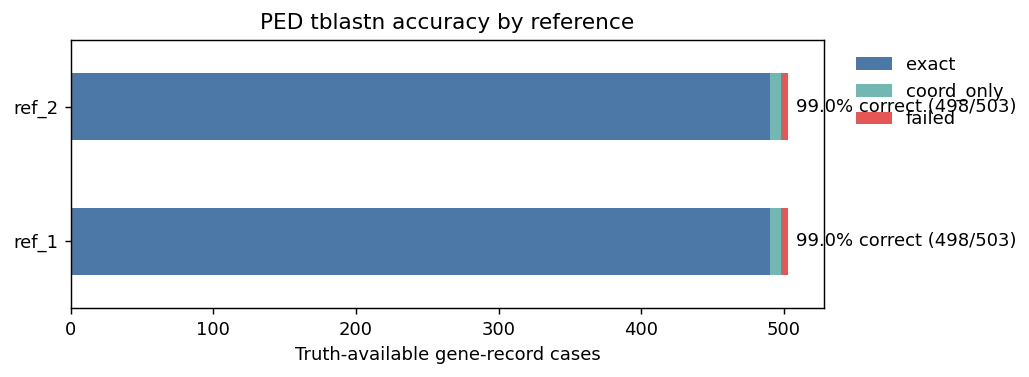

In [7]:
plot_df = overall_accuracy.set_index('ref')[['exact', 'coord_only', 'failed']]
colors = ['#4c78a8', '#72b7b2', '#e45756']
ax = plot_df.plot(kind='barh', stacked=True, figsize=(8, 3), color=colors)
ax.set_title('PED tblastn accuracy by reference')
ax.set_xlabel('Truth-available gene-record cases')
ax.set_ylabel('')
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
for i, (ref, row) in enumerate(plot_df.iterrows()):
    total = row.sum()
    correct = row['exact'] + row['coord_only']
    ax.text(total + max(plot_df.sum(axis=1)) * 0.01, i, f'{correct/total*100:.1f}% correct ({correct}/{total})', va='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'ped_tblastn_accuracy_by_ref_{RUN_SUFFIX}.png', bbox_inches='tight')
plt.show()

## Per-Gene Accuracy

Mỗi gene chỉ được tính trên records có truth gene đó. Đây là bảng quan trọng nhất để đọc gene nào tốt/xấu.

In [8]:
per_gene_accuracy = summarize_truth_available(ped_tblastn_df, ['ref', 'ref_record', 'pred_name'])
per_gene_accuracy = per_gene_accuracy.rename(columns={'pred_name': 'gene'})
per_gene_accuracy = per_gene_accuracy.sort_values(['ref', 'gene'])
per_gene_accuracy.to_csv(OUTPUT_DIR / f'ped_tblastn_per_gene_accuracy_{RUN_SUFFIX}.tsv', sep='	', index=False)
per_gene_accuracy

,ref,ref_record,gene,total,exact,coord_correct,mean_iou,coord_only,failed,exact_pct,correct_pct
0,ref_1,PZ105934.1,E,96,96,96,1.0000,0,0,100.00,100.00
1,ref_1,PZ105934.1,M,97,97,97,1.0000,0,0,100.00,100.00
2,ref_1,PZ105934.1,N,97,95,96,0.9901,1,1,97.94,98.97
3,ref_1,PZ105934.1,ORF1a,17,17,17,1.0000,0,0,100.00,100.00
4,ref_1,PZ105934.1,ORF1b,8,3,7,0.9085,4,1,37.50,87.50
5,ref_1,PZ105934.1,ORF3,91,88,89,0.9885,1,2,96.70,97.80
6,ref_1,PZ105934.1,S,97,94,96,0.9912,2,1,96.91,98.97
7,ref_2,PV974486.1,E,96,96,96,1.0000,0,0,100.00,100.00
8,ref_2,PV974486.1,M,97,97,97,1.0000,0,0,100.00,100.00
9,ref_2,PV974486.1,N,97,95,96,0.9901,1,1,97.94,98.97


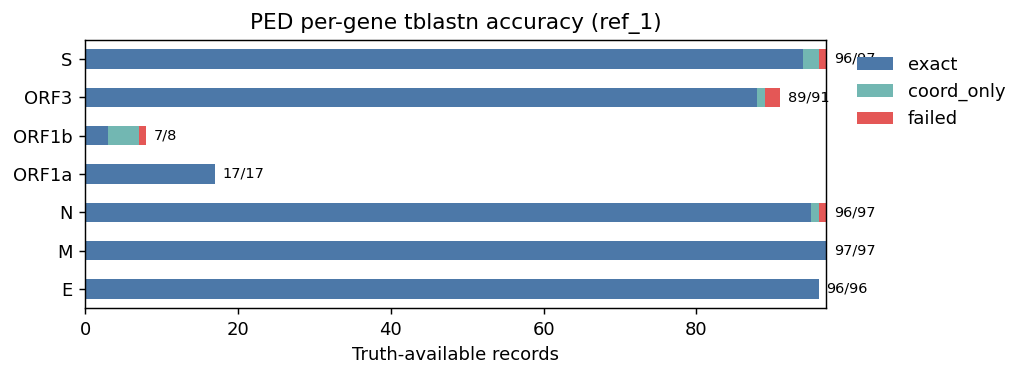

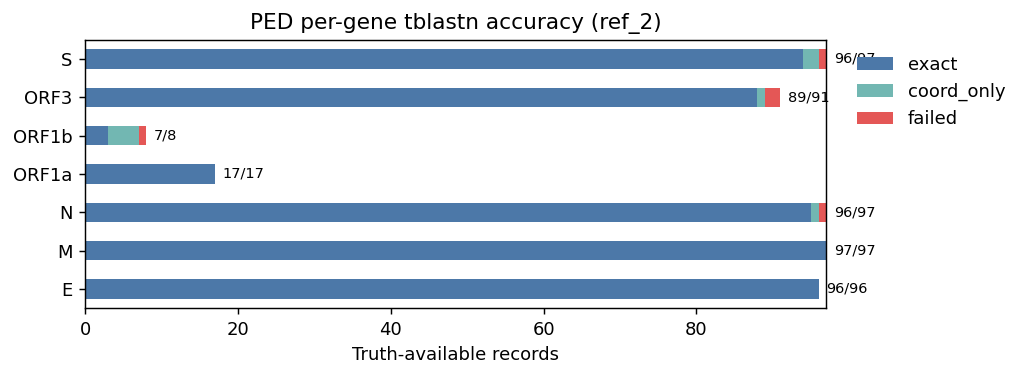

In [9]:
for ref_label, group in per_gene_accuracy.groupby('ref'):
    data = group.set_index('gene')[['exact', 'coord_only', 'failed']].sort_index()
    ax = data.plot(kind='barh', stacked=True, figsize=(8, max(3, 0.35 * len(data))), color=['#4c78a8', '#72b7b2', '#e45756'])
    ax.set_title(f'PED per-gene tblastn accuracy ({ref_label})')
    ax.set_xlabel('Truth-available records')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    for i, (gene, row) in enumerate(data.iterrows()):
        total = row.sum()
        correct = row['exact'] + row['coord_only']
        ax.text(total + max(data.sum(axis=1)) * 0.01, i, f'{correct}/{total}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'ped_tblastn_per_gene_{ref_label}_{RUN_SUFFIX}.png', bbox_inches='tight')
    plt.show()

## Failure Breakdown

Bảng dưới chỉ gồm truth-available cases nhưng không exact. Dùng để xem failure là lệch boundary nhỏ, wrong coords, no hit, hay low coverage.

In [10]:
failures = ped_tblastn_df[
    ped_tblastn_df['truth_name'].notna() & ~ped_tblastn_df['exact_match'].fillna(False)
].copy()
for col in ['pred_start', 'pred_end', 'truth_start', 'truth_end', 'iou', 'best_iou', 'coverage', 'identity']:
    failures[col] = pd.to_numeric(failures[col], errors='coerce')
failures['delta_start'] = failures['pred_start'] - failures['truth_start']
failures['delta_end'] = failures['pred_end'] - failures['truth_end']
failures.to_csv(OUTPUT_DIR / f'ped_tblastn_failures_{RUN_SUFFIX}.tsv', sep='	', index=False)

failure_summary = (
    failures.groupby(['ref', 'pred_name', 'failure_mode', 'status'], dropna=False)
    .agg(
        cases=('record_id', 'size'),
        mean_iou=('iou', 'mean'),
        median_delta_start=('delta_start', 'median'),
        median_delta_end=('delta_end', 'median'),
        examples=('record_id', lambda s: ', '.join(sorted(set(s))[:6]) + (' ...' if s.nunique() > 6 else '')),
    )
    .reset_index()
    .sort_values(['ref', 'cases'], ascending=[True, False])
)
failure_summary['mean_iou'] = failure_summary['mean_iou'].round(4)
failure_summary.to_csv(OUTPUT_DIR / f'ped_tblastn_failure_summary_{RUN_SUFFIX}.tsv', sep='	', index=False)
failure_summary

,ref,pred_name,failure_mode,status,cases,mean_iou,median_delta_start,median_delta_end,examples
3,ref_1,ORF1b,Boundary offset,ok_rescued,3,0.9775,195.0,0.0,"MF577027.1, PQ878525.1, PV974486.1"
6,ref_1,ORF3,Wrong coords,invalid_boundaries,2,0.5110,0.0,325.5,"OP326239.1, PV533621.1"
7,ref_1,S,Boundary offset,ok_rescued,2,0.9920,-18.0,15.0,"KP765609.1, MF577027.1"
0,ref_1,N,Boundary offset,ok_rescued,1,0.9886,0.0,15.0,MF577027.1
1,ref_1,N,Wrong coords,ok_rescued,1,0.0478,-26442.0,0.0,OR085251.1
2,ref_1,ORF1b,Boundary offset,invalid_boundaries,1,0.9508,0.0,385.0,PX146708.1
4,ref_1,ORF1b,Wrong coords,ok_rescued,1,0.3847,12518.0,0.0,KX550281.1
5,ref_1,ORF3,Boundary offset,invalid_boundaries,1,0.9350,0.0,44.0,MF462814.1
8,ref_1,S,Wrong coords,invalid_boundaries,1,0.1668,-20792.0,0.0,PV536098.1
11,ref_2,ORF1b,Boundary offset,ok_rescued,4,0.9647,165.0,0.0,"MF577027.1, PQ878525.1, PV974486.1, PX146708.1"


## ORF1ab Granularity Audit

PED query records thường có `ORF1ab` gộp. Hai reference hiện tại chỉ có `ORF1a` và `ORF1b`, nên `ORF1ab` không được tính vào tblastn denominator của ref genes. Đây là annotation granularity mismatch, không phải alias sai.

Cell này audit trên toàn bộ 100 records, không phụ thuộc `SAMPLE_N`.

In [11]:
orf1ab_records = sorted(truth_all.loc[truth_all['truth_name'].eq('ORF1ab'), 'record_id'].unique())
orf1a_records = sorted(truth_all.loc[truth_all['truth_name'].eq('ORF1a'), 'record_id'].unique())
orf1b_records = sorted(truth_all.loc[truth_all['truth_name'].eq('ORF1b'), 'record_id'].unique())
orf_audit = pd.DataFrame([
    {'truth_gene': 'ORF1ab', 'records': len(orf1ab_records), 'examples': ', '.join(orf1ab_records[:8]) + (' ...' if len(orf1ab_records) > 8 else '')},
    {'truth_gene': 'ORF1a', 'records': len(orf1a_records), 'examples': ', '.join(orf1a_records[:8]) + (' ...' if len(orf1a_records) > 8 else '')},
    {'truth_gene': 'ORF1b', 'records': len(orf1b_records), 'examples': ', '.join(orf1b_records[:8]) + (' ...' if len(orf1b_records) > 8 else '')},
])
orf_audit.to_csv(OUTPUT_DIR / 'ped_orf1_granularity_audit.tsv', sep='	', index=False)
orf_audit

,truth_gene,records,examples
0,ORF1ab,62,"JX112709.1, JX489155.1, KC210147.1, KP765609.1, KX981440.1, KY007139.1, MF375374.1, MK071637.1 ..."
1,ORF1a,17,"MF577027.1, OL347994.1, OL762457.1, OP784565.1, OQ589489.1, PP107944.1, PV125746.1, PV974486.1 ..."
2,ORF1b,8,"KX550281.1, MF577027.1, OL762457.1, PP987385.1, PQ878525.1, PV974486.1, PX146708.1, PZ105934.1"


## Short Takeaway Template

Sau khi chạy notebook:

1. So `overall_accuracy` giữa `ref_1` và `ref_2`.
2. Đọc `per_gene_accuracy` để xem gene nào kéo accuracy xuống.
3. Với các gene fail, đọc `failure_summary` và `ped_tblastn_failures.tsv`.
4. Không tính `ORF1ab` vào lỗi của tblastn nếu reference không có `ORF1ab`.


In [12]:
failures[failures['pred_name'].eq('ORF1b')][
    ['ref', 'record_id', 'pred_start', 'truth_start', 'delta_start',
     'pred_end', 'truth_end', 'delta_end', 'iou', 'status', 'failure_mode']
]

,ref,record_id,pred_start,truth_start,delta_start,pred_end,truth_end,delta_end,iou,status,failure_mode
36,ref_1,KX550281.1,12811,293.0,12518.0,20637,20637.0,0.0,0.3847,ok_rescued,Wrong coords
57,ref_1,MF577027.1,12810,12675.0,135.0,20636,20636.0,0.0,0.9830,ok_rescued,Boundary offset
379,ref_1,PQ878525.1,12812,12602.0,210.0,20638,20638.0,0.0,0.9739,ok_rescued,Boundary offset
512,ref_1,PV974486.1,12789,12594.0,195.0,20615,20615.0,0.0,0.9757,ok_rescued,Boundary offset
519,ref_1,PX146708.1,12812,12812.0,0.0,20642,20257.0,385.0,0.9508,invalid_boundaries,Boundary offset
722,ref_2,KX550281.1,12811,293.0,12518.0,20637,20637.0,0.0,0.3847,ok_rescued,Wrong coords
743,ref_2,MF577027.1,12810,12675.0,135.0,20636,20636.0,0.0,0.9830,ok_rescued,Boundary offset
1065,ref_2,PQ878525.1,12812,12602.0,210.0,20638,20638.0,0.0,0.9739,ok_rescued,Boundary offset
1198,ref_2,PV974486.1,12789,12594.0,195.0,20615,20615.0,0.0,0.9757,ok_rescued,Boundary offset
1205,ref_2,PX146708.1,12603,12812.0,-209.0,20642,20257.0,385.0,0.9261,ok_rescued,Boundary offset
